## Lookup Table generálása a kimeneti függvényekhez

Elsőször megvizsgáltam a dokumentációban ([https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master](https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master)) szereplő sigmoid függvényt.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import torch
from torch import nn

In [108]:
with open("sigmoid", "r") as f:
    lines = f.readlines()
    sigmoid_values = []
    for line in lines:
        parts = line.split(":")
        if len(parts) > 1:
            value_part = parts[1].strip().rstrip(";")
            try:
                value = int(value_part)
                sigmoid_values.append(value)
            except ValueError:
                continue

plt.plot(sigmoid_values)
plt.title("Sigmoid lookup table")
plt.xlabel("Input index")
plt.ylabel("Quantized sigmoid value")
plt.show()

from collections import Counter
value_counts = Counter(sigmoid_values)
for value, count in value_counts.items():
    print(f"Érték: {value}, Darabszám: {count}")

FileNotFoundError: [Errno 2] No such file or directory: 'sigmoid'

### Alább az öt darab aktivációs függvény megvalósítása LUT-okkal

Sigmoid: 

In [2]:
def sigmoid_generator(inwidth, outwidth, beta):
    my_sigmoid = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta)) # ezekk a 2^(int_scale+weight_scale) # 6 + 4 = 0

    for i in range(round(-inwidth/2), round(inwidth/2)):
        my_sigmoid[i] = beta/(1 + np.exp(-i/beta)) 

    
    plt.plot(list(my_sigmoid.values()))
    plt.title("Sigmoid LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized sigmoid value")
    plt.grid()
    plt.show()

    with open("my_sgimoid_lookup_table.txt", "w") as f:
        for key in sorted(my_sigmoid.keys()):
            f.write(f"{my_sigmoid[key]},\n")

    #behúzza a pozitív féltengelyre
    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_sigmoid.items()}
    my_sigmoid = new_d

    return my_sigmoid

Relu:

In [4]:
def relu_generator(inwidth):

    relu_table = {}
    
    inwidth = int(np.exp2(inwidth))
    
    for i in range(round(-inwidth/2), round(inwidth/2)):
        relu_table[i] = max(0, i)

    plt.plot(list(relu_table.values()))
    plt.title("ReLU LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized ReLU value")
    plt.show()

    with open("relu_lookup_table.txt", "w") as f:
        for key in sorted(relu_table.keys()):
            f.write(f"{relu_table[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in relu_table.items()}
    relu_table = new_d

    return relu_table

Softplus:

In [5]:
def softplus_generator(inwidth, outwidth, beta):
    my_softplus = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    function = nn.Softplus(1/beta)

    for i in range(round(-inwidth/2), round(inwidth/2)):
        x = torch.tensor(float(i))
        my_softplus[i] = function(x).item()

    plt.plot(list(my_softplus.values()))
    plt.title("Softplus LUT")
    plt.xlabel("Input index")
    plt.ylabel("Quantized softplus value")
    plt.grid()
    plt.show()

    with open("my_softplus_lookup_table.txt", "w") as f:
        for key in sorted(my_softplus.keys()):
            f.write(f"{my_softplus[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_softplus.items()}
    my_softplus = new_d

    return my_softplus

Tanh:

In [6]:
def tanh_generator(inwidth, outwidth, beta):
    my_tanh = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    for i in range(round(-inwidth/2), round(inwidth/2)):
        my_tanh[i] = beta*np.tanh(i/beta)

    plt.plot(list(my_tanh.values()))
    plt.title("My Tanh approximation")
    plt.xlabel("Input index")
    plt.ylabel("Quantized tanh value")
    plt.grid()
    plt.show()

    with open("my_tanh_lookup_table.txt", "w") as f:
        for key in sorted(my_tanh.keys()):
            f.write(f"{my_tanh[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_tanh.items()}
    my_tanh = new_d

    return my_tanh

Leaky Relu:

In [7]:
def leaky_relu_generator(inwidth, outwidth, beta):
    my_leaky_relu = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = int(np.exp2(beta))

    for i in range(round(-inwidth/2), round(inwidth/2)):
        if i < 0:
            my_leaky_relu[i] = i * 0.01
        else :
            my_leaky_relu[i] = i

    plt.plot(list(my_leaky_relu.values()))
    plt.title("Leaky Relu approximation")
    plt.xlabel("Input index")
    plt.ylabel("Quantized tanh value")
    plt.grid()
    plt.show()

    with open("my_leaky_relu_lookup_table.txt", "w") as f:
        for key in sorted(my_leaky_relu.keys()):
            f.write(f"{my_leaky_relu[key]},\n")
    

#### LUT + Lineáris interpoláció

A Leaky Relu-t és a Relut nem fogom ezzel a megoldással implementálni, mivel mindkét függvény egyszerűen számolhaló az elágazással és a generálási függvénnyel. Először definiálom a szükséges segédfüggvényeket.

In [8]:
def generate_pwl_switch(name, activation_values, size, num_of_points, shift):

    param = int(size / num_of_points)
    x_values = []
    y_values = []

    for i in range(size):
        if i % param == 0:
            x_values.append(i)
            y_values.append(activation_values[i])

    # utolsó pont hozzáadása
    x_values.append(size - 1)
    y_values.append(activation_values[size - 1])

    a = []
    b = []
    k_values = []
    segments = []

    for i in range(len(x_values) - 1):
        ai = (y_values[i+1] - y_values[i]) / (x_values[i+1] - x_values[i])
        bi = y_values[i] - ai * x_values[i]
        k = round(ai * (2**shift))
        a.append(ai)
        b.append(int(round(bi)))
        k_values.append(k)
        segments.append((x_values[i], x_values[i+1], ai, bi, k))

    print(f"ap_uint<18> {name}(ap_uint<18> x){{")
    print(f"    int interval = x >> {shift};")
    print(f"    switch (interval){{")

    for idx, (k, bi) in enumerate(zip(k_values, b)):
        print(f"        case {idx}: return ((x * {k}) >> {shift}) + {bi};")

    print("        default: return {255};")
    print("    }    ")
    print("}")    

    return segments

In [9]:
def plot_pwl_error(activation_values, segments, title="PWL Approximation Error"):

    # diszkrét x értékek
    x_all = sorted(activation_values.keys())
    y_orig = np.array([activation_values[x] for x in x_all])

    # PWL értékek kiszámítása diszkréten
    y_pwl = []
    for x in x_all:
        for (x0, x1, a, b, _) in segments:
            if x0 <= x <= x1:
                y_pwl.append(a * x + b)
                break
    y_pwl = np.array(y_pwl)

    # különbség
    diff = y_orig - y_pwl

    # statisztika
    mean_err = np.mean(diff)
    mae = np.mean(np.abs(diff))
    max_err = np.max(np.abs(diff))
    std_err = np.std(diff)

    print("=== PWL Approximation Error Statistics ===")
    print(f"Átlagos hiba      : {mean_err:.6f}")
    print(f"Átlagos absz. hiba: {mae:.6f}")
    print(f"Maximum hiba      : {max_err:.6f}")
    print(f"Szórás            : {std_err:.6f}")

    # plot
    plt.figure(figsize=(10,6))
    plt.plot(x_all, diff, color="red", label="Eredeti - PWL")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("x")
    plt.ylabel("Eltérés")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
def draw_pwl(segments):
    plt.figure(figsize=(10,6))

    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1)
        y = a * x + b
        plt.plot(x, y, label=f"[{x0:.0f},{x1:.0f}]")
        
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Darabolt lineáris közelítés")
    #plt.legend()
    plt.grid(True)
    plt.show()


In [11]:
def draw_error(original, segments):
    plt.figure(figsize=(10,6))

    x_orig = sorted(original.keys())
    y_orig = [original[x] for x in x_orig]
    plt.plot(x_orig, y_orig, label="Eredeti (original)", color="black")

    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1, 200)
        y = a * x + b
        plt.plot(x, y, label=f"PWL [{x0:.0f},{x1:.0f}]")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Original vs. darabolt lineáris közelítés")
    #plt.legend()
    plt.grid(True)
    plt.show()

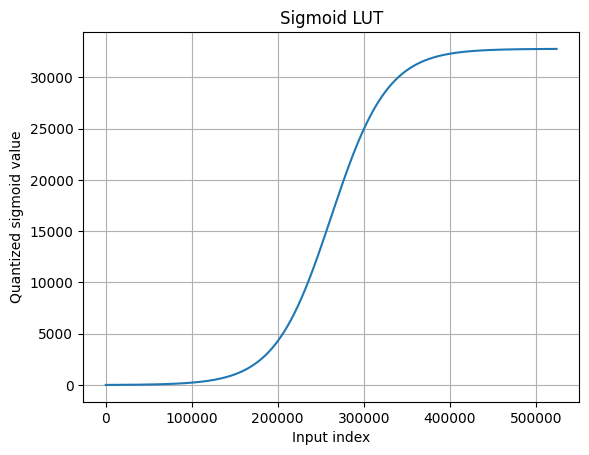

ap_uint<18> pwl_sigmoid(ap_uint<18> x){
    int interval = x >> 15;
    switch (interval){
        case 0: return ((x * 14) >> 15) + 11;
        case 1: return ((x * 23) >> 15) + 6;
        case 2: return ((x * 39) >> 15) + -9;
        case 3: return ((x * 64) >> 15) + -46;
        case 4: return ((x * 105) >> 15) + -128;
        case 5: return ((x * 172) >> 15) + -296;
        case 6: return ((x * 281) >> 15) + -625;
        case 7: return ((x * 459) >> 15) + -1245;
        case 8: return ((x * 742) >> 15) + -2380;
        case 9: return ((x * 1187) >> 15) + -4381;
        case 10: return ((x * 1863) >> 15) + -7763;
        case 11: return ((x * 2841) >> 15) + -13138;
        case 12: return ((x * 4143) >> 15) + -20954;
        case 13: return ((x * 5670) >> 15) + -30877;
        case 14: return ((x * 7117) >> 15) + -41007;
        case 15: return ((x * 8025) >> 15) + -47820;
        case 16: return ((x * 8025) >> 15) + -47820;
        case 17: return ((x * 7117) >> 15) + -40099;
    

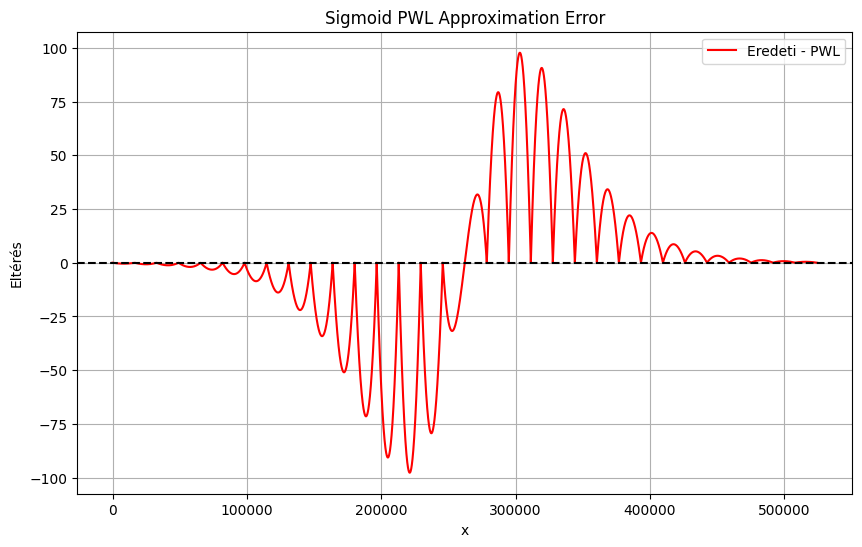

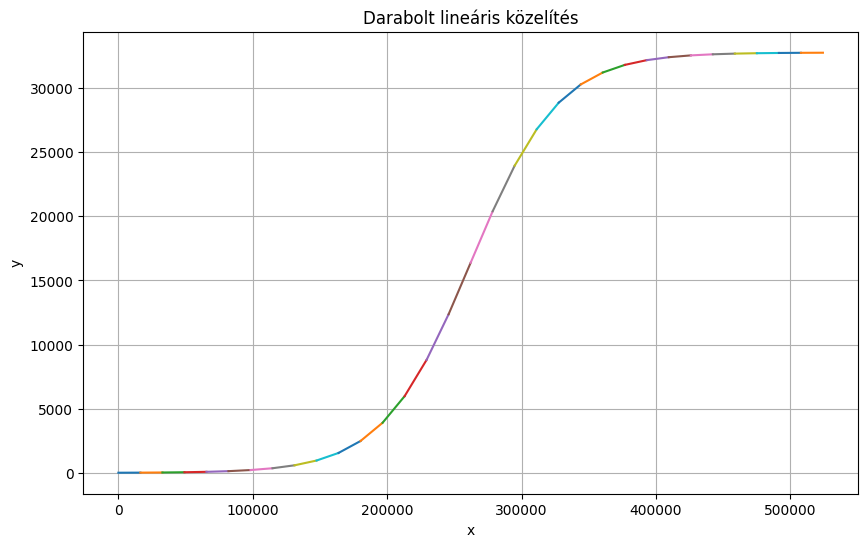

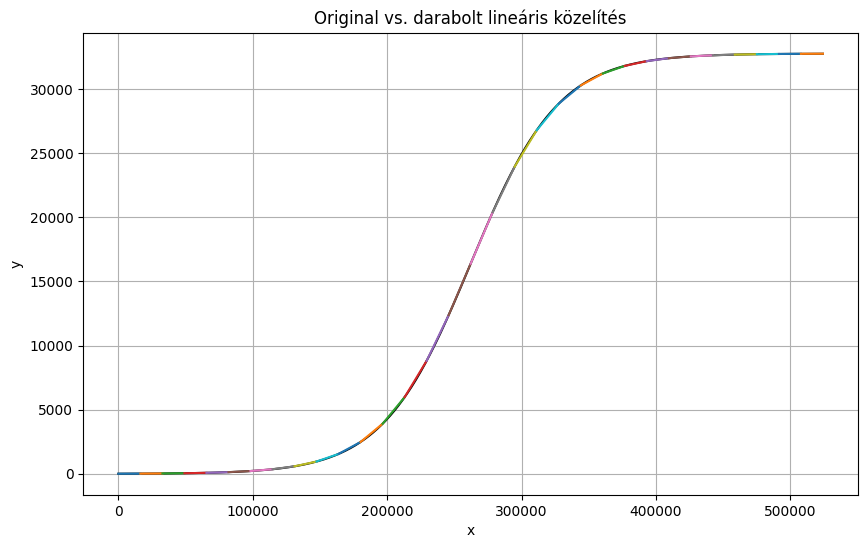

In [12]:
inwidth = 19
outwidth = 19
beta = 15

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
plot_pwl_error(my_sigmoid, segments, title="Sigmoid PWL Approximation Error")
draw_pwl(segments)
draw_error(my_sigmoid, segments)

Eddig minden jó, de!

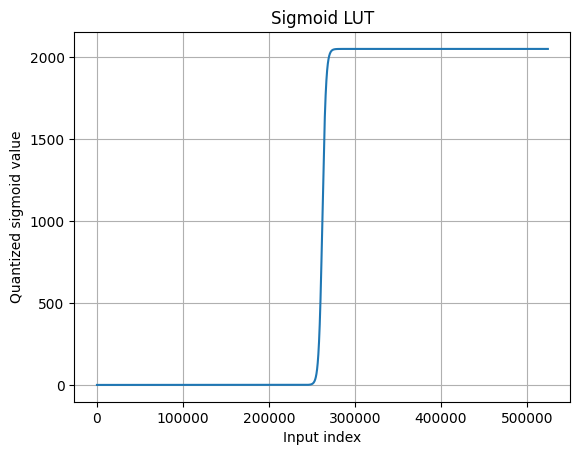

ap_uint<18> pwl_sigmoid(ap_uint<18> x){
    int interval = x >> 11;
    switch (interval){
        case 0: return ((x * 0) >> 11) + 0;
        case 1: return ((x * 0) >> 11) + 0;
        case 2: return ((x * 0) >> 11) + 0;
        case 3: return ((x * 0) >> 11) + 0;
        case 4: return ((x * 0) >> 11) + 0;
        case 5: return ((x * 0) >> 11) + 0;
        case 6: return ((x * 0) >> 11) + 0;
        case 7: return ((x * 0) >> 11) + 0;
        case 8: return ((x * 0) >> 11) + 0;
        case 9: return ((x * 0) >> 11) + 0;
        case 10: return ((x * 0) >> 11) + 0;
        case 11: return ((x * 0) >> 11) + 0;
        case 12: return ((x * 0) >> 11) + 0;
        case 13: return ((x * 0) >> 11) + 0;
        case 14: return ((x * 0) >> 11) + -10;
        case 15: return ((x * 128) >> 11) + -15349;
        case 16: return ((x * 128) >> 11) + -15349;
        case 17: return ((x * 0) >> 11) + 2036;
        case 18: return ((x * 0) >> 11) + 2048;
        case 19: return ((x * 0) >> 11) + 

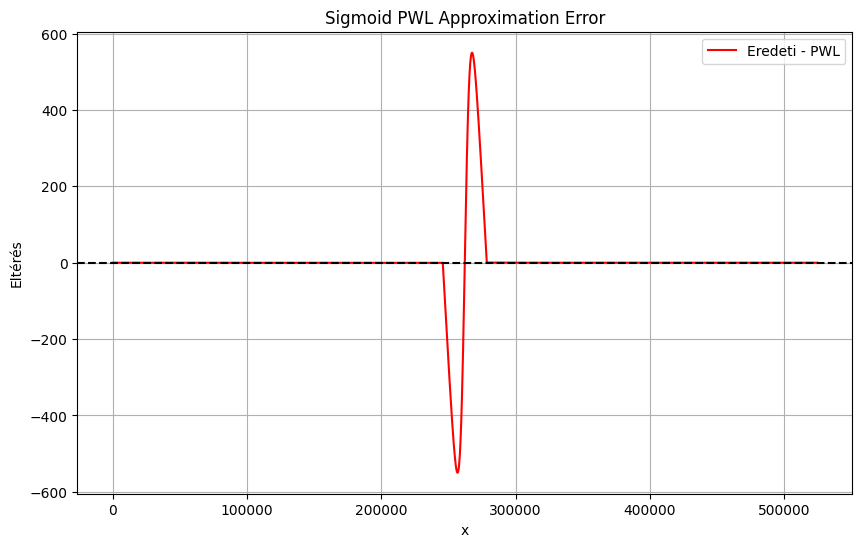

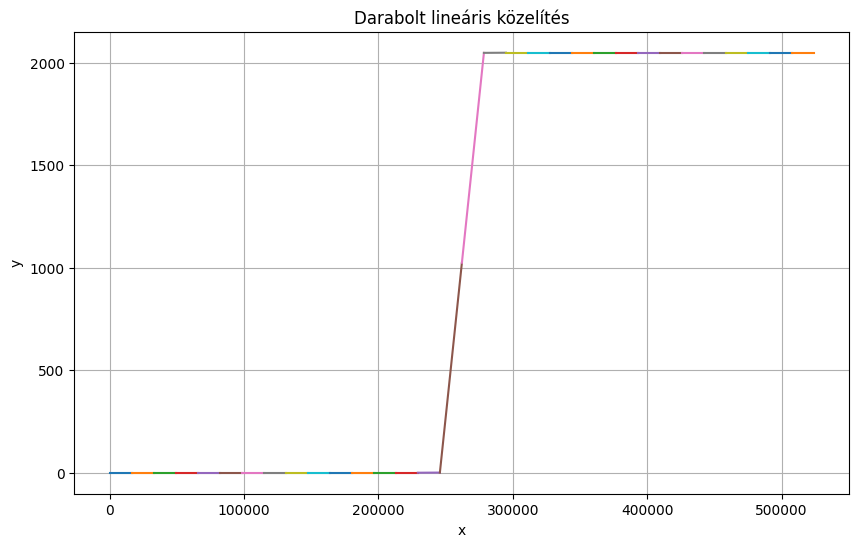

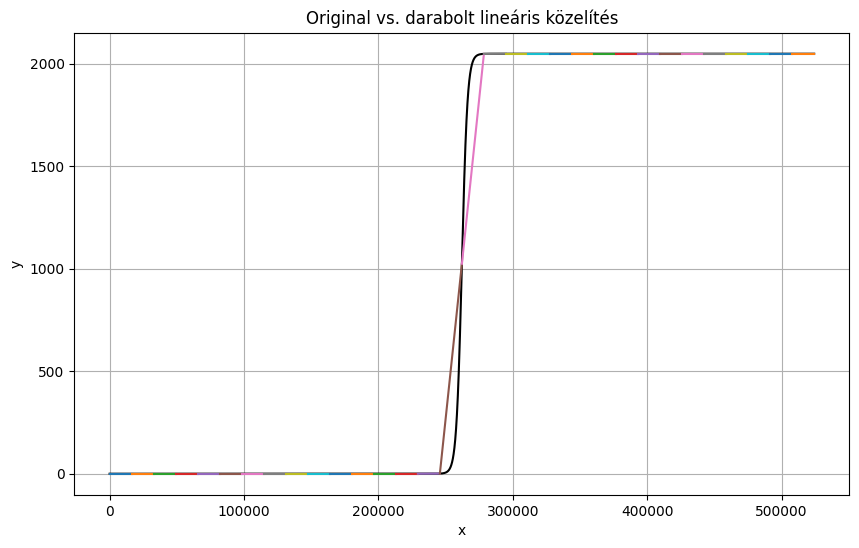

In [13]:
inwidth = 19
outwidth = 19
beta = 11

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
plot_pwl_error(my_sigmoid, segments, title="Sigmoid PWL Approximation Error")
draw_pwl(segments)
draw_error(my_sigmoid, segments)

In [14]:
print(segments)
for (x0, x1, a, b, k) in segments:
    #print(f"x0: {x0}, x1: {x1}, a: {a}, b: {b}")
    print(f"y = {a}*x + {b}")
    #print(f"k = {k}")
    print(f"((x * {k}) >> 14) + {int(b)}")

[(0, 16384, np.float64(9.581344830436697e-54), np.float64(5.2678847951716655e-53), 0), (16384, 32768, np.float64(2.856158639889125e-50), np.float64(-4.677959981268844e-46), 0), (32768, 49152, np.float64(8.514088909835725e-47), np.float64(-2.7894285439099782e-42), 0), (49152, 65536, np.float64(2.5380141338158205e-43), np.float64(-1.247345165409447e-38), 0), (65536, 81920, np.float64(7.565713503423064e-40), np.float64(-4.957850033826011e-35), 0), (81920, 98304, np.float64(2.255307409569844e-36), np.float64(-1.8474238316727983e-31), 0), (98304, 114688, np.float64(6.722976635791616e-33), np.float64(-6.608585318484359e-28), 0), (114688, 131072, np.float64(2.0040910899157947e-29), np.float64(-2.2983418029900696e-24), 0), (131072, 147456, np.float64(5.97411134124365e-26), np.float64(-7.830058756724493e-21), 0), (147456, 163840, np.float64(1.7808574918156832e-22), np.float64(-2.625883310445472e-17), 0), (163840, 180224, np.float64(5.30866136401106e-19), np.float64(-8.697418905191575e-14), 0), 